In [11]:
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [12]:
data = pd.read_csv("02_final_featured_data.csv")

In [22]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(data, data["Churn"]):
    strat_train_set = data.loc[train_index]
    strat_test_set = data.loc[test_index]

In [23]:
X_train = strat_train_set.drop(["customerID", "Churn"], axis=1)
y_train = strat_train_set["Churn"]

X_train = pd.get_dummies(X_train)

In [24]:
X_test = strat_test_set.drop(["customerID", "Churn"], axis=1)
y_test = strat_test_set["Churn"]

X_test = pd.get_dummies(X_test)

In [25]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [26]:
model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [30]:
probs = model.predict_proba(X_test)[:,1]
preds = (probs > 0.3).astype(int)
print("Threshold:", 0.3)
print(confusion_matrix(y_test, preds))

Threshold: 0.3
[[626 407]
 [ 46 328]]


In [19]:
print(classification_report(y_test, preds))
print(confusion_matrix(y_test, preds))

              precision    recall  f1-score   support

           0       0.93      0.61      0.73      1033
           1       0.45      0.88      0.59       374

    accuracy                           0.68      1407
   macro avg       0.69      0.74      0.66      1407
weighted avg       0.80      0.68      0.70      1407

[[626 407]
 [ 46 328]]


In [20]:
for t in [0.3, 0.35, 0.4]:
    preds = (probs > t).astype(int)
    print("Threshold:", t)
    print(confusion_matrix(y_test, preds))

Threshold: 0.3
[[626 407]
 [ 46 328]]
Threshold: 0.35
[[671 362]
 [ 55 319]]
Threshold: 0.4
[[714 319]
 [ 67 307]]


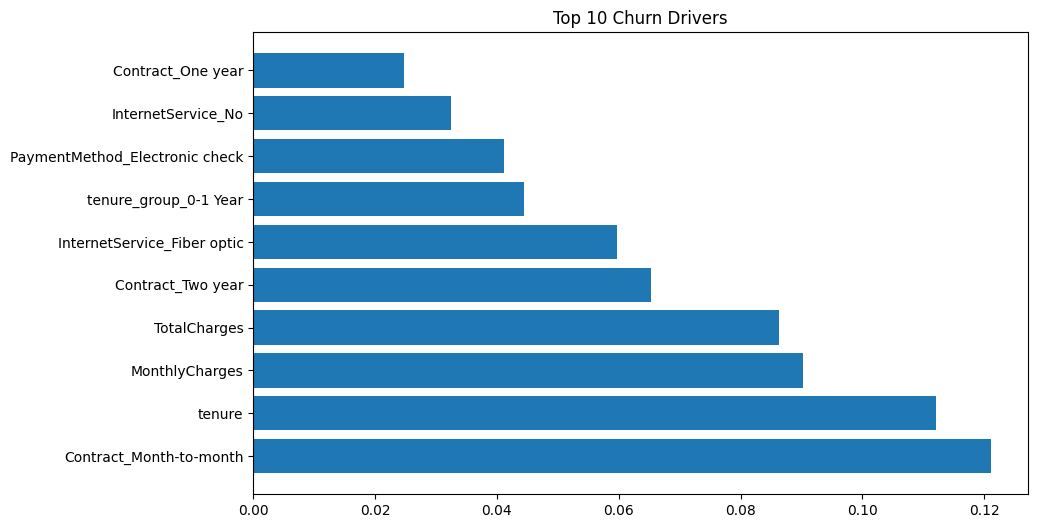

In [21]:
import matplotlib.pyplot as plt

# Importance nikaalo
importances = model.feature_importances_
feature_names = X_test.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Top 10 features dekho
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot karo
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.title('Top 10 Churn Drivers')
plt.show()

In [32]:
feature_importance_df.to_csv("feature_importance.csv", index=False)

In [39]:
a  = data.drop(["customerID"],axis = 1)
a = pd.get_dummies(a)
a

,tenure,MonthlyCharges,TotalCharges,Churn,total_services,gender_Female,gender_Male,SeniorCitizen_No,SeniorCitizen_Yes,Partner_No,...,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_0-1 Year,tenure_group_1-2 Years,tenure_group_2-4 Years,tenure_group_4-5 Years,tenure_group_5+ Years
0,1,29.85,29.85,0,1,True,False,True,False,False,...,True,False,False,True,False,True,False,False,False,False
1,34,56.95,1889.50,0,2,False,True,True,False,True,...,False,False,False,False,True,False,False,True,False,False
2,2,53.85,108.15,1,2,False,True,True,False,True,...,True,False,False,False,True,True,False,False,False,False
3,45,42.30,1840.75,0,3,False,True,True,False,True,...,False,True,False,False,False,False,False,True,False,False
4,2,70.70,151.65,1,0,True,False,True,False,True,...,True,False,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,24,84.80,1990.50,0,5,False,True,True,False,False,...,True,False,False,False,True,False,True,False,False,False
7028,72,103.20,7362.90,0,4,True,False,True,False,False,...,True,False,True,False,False,False,False,False,False,True
7029,11,29.60,346.45,0,1,True,False,True,False,False,...,True,False,False,True,False,True,False,False,False,False
7030,4,74.40,306.60,1,0,False,True,False,True,False,...,True,False,False,False,True,True,False,False,False,False
